<a href="https://colab.research.google.com/github/Mera-M02/Telco-Customer-Churn-Prediction/blob/main/Telco_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 1 : Setting Up the Libraries and tools**



This section installs the additional libraries which is not inlcuded in google Colab and imports all the tools used throughout the analysis.

In [ ]:
#Install Libraries for class imbalanced and shap
!pip install imbalanced-learn shap -q

In [ ]:
#Tools for data handling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#Machine learning and preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [ ]:
#Connecting Google Drive access to the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Section 2: Loading the Data**

In [ ]:
#Loading the data
df = pd.read_csv("/content/drive/MyDrive/Notebooks/CRP/Telco_customer_churn.csv")
print(f"Rows: {df.shape[0]} Columns:{df.shape[1]}")

Rows: 7043 Columns:33


# **Section 3: Exploring the Data (EDA)**

In [ ]:
#Get all the Column Names
print("Column Names: ")
for c in df.columns:
  print(" ",c)

Column Names: 
  CustomerID
  Count
  Country
  State
  City
  Zip Code
  Lat Long
  Latitude
  Longitude
  Gender
  Senior Citizen
  Partner
  Dependents
  Tenure Months
  Phone Service
  Multiple Lines
  Internet Service
  Online Security
  Online Backup
  Device Protection
  Tech Support
  Streaming TV
  Streaming Movies
  Contract
  Paperless Billing
  Payment Method
  Monthly Charges
  Total Charges
  Churn Label
  Churn Value
  Churn Score
  CLTV
  Churn Reason


In [ ]:
#Getting the first 5 rows
print("First 5 Rows: ")
df.head()

First 5 Rows: 


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
#Show the data types of each column
print("Data Types")
df.dtypes

Data Types


,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [ ]:
#Summary Statistics for each columns
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


# **Section4: Checking and Fixing the Missing Values & Data Types**

In [ ]:
#Check for the missing values
print("Missing Values: ")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing Values: 
Churn Reason    5174
dtype: int64


In [ ]:
#Checking the datatype
df["Total Charges"].dtype

dtype('O')

In [ ]:
#Converting the Total Charges to numeric & fill blanks with median
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

# **Section 5: Creating A Target Variable**

In [ ]:
if "Churn Value" in df.columns:
    df["target"] = df["Churn Value"]

print("Churn distribution:")
print(df["target"].value_counts())
print((df["target"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")

Churn distribution:
target
0    5174
1    1869
Name: count, dtype: int64
target
0    73.5 %
1    26.5 %
Name: proportion, dtype: object


# **Section 6: Dropping the Churn (leakage Columns)**

In [ ]:
#Listing all the columns to drop
dropped_cols = [
    "CustomerID", "Count", "Country", "State", "City",
    "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Value",
    "Churn Score", "Churn Category", "Customer Status",
    "Satisfaction Score", "CLTV", "Churn Reason",
]

#Keeping CLTV and Churn Reason for later
req_cols = {}
for col in ["CLTV", "Churn Reason"]:
    if col in df.columns:
        req_cols[col] = df[col].copy()
        print(f"Saved '{col}' for later.")

to_drop = [c for c in dropped_cols if c in df.columns]
X = df.drop(columns=to_drop + ["target"])
y = df["target"]
print(f"Dropped {len(to_drop)} columns. Features remaining: {X.shape[1]}")

Saved 'CLTV' for later.
Saved 'Churn Reason' for later.
Dropped 14 columns. Features remaining: 19


# **Section7 : Encoding Categorical Features**

In [ ]:
X = pd.get_dummies(X, drop_first=True)
print(f"After encoding: {X.shape[1]} features")

After encoding: 30 features


# **Section 8: Spliiting into Trainig and Testing Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")

Train: 5634 rows   Test: 1409 rows


# **Section 9: Scalling the numbers**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled")

Scaled


# **Section 10: Balancing the classes with Smote**

In [ ]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE, training distribution:")
print(pd.Series(y_train_balanced).value_counts())

After SMOTE, training distribution:
target
0    4139
1    4139
Name: count, dtype: int64


# **Section 11: Creating EDA Charts**

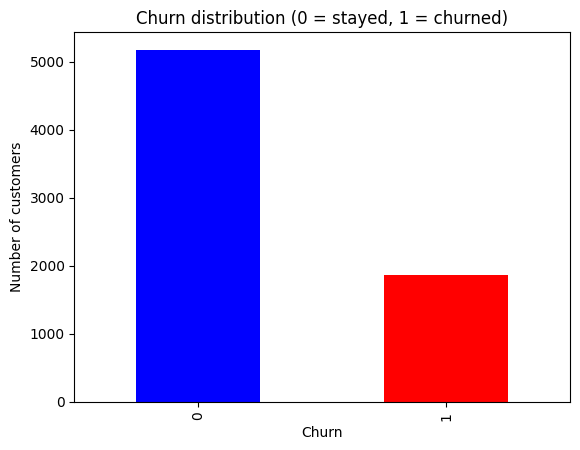

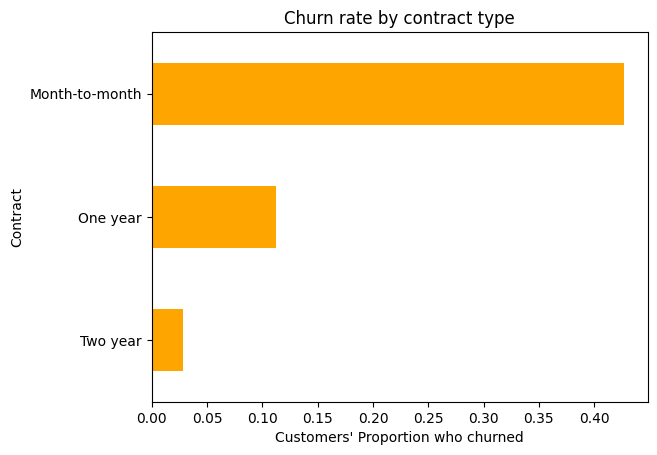

In [ ]:
#Overall Churn Distribution Chart
df["target"].value_counts().plot(kind="bar", color=["blue", "red"])
plt.title("Churn distribution (0 = stayed, 1 = churned)")
plt.xlabel("Churn"); plt.ylabel("Number of customers")
plt.show()

#Churn rate by Contract Type
if "Contract" in df.columns:
    df.groupby("Contract")["target"].mean().sort_values().plot(
        kind="barh", color="orange")
    plt.title("Churn rate by contract type")
    plt.xlabel("Customers' Proportion who churned")
    plt.show()

# **Section 12: Final Check**

In [ ]:
print("X_train_balanced:", X_train_balanced.shape)
print("y_train_balanced:", y_train_balanced.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_test:", y_test.shape)

X_train_balanced: (8278, 30)
y_train_balanced: (8278,)
X_test_scaled: (1409, 30)
y_test: (1409,)


# **Section 13: Modelling Comparison**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
import pandas as pd

#Define Models to compare
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state = 42),
    "Random Forest": RandomForestClassifier(random_state = 42),
}

results = []
for name, model in models.items():
  #Train model on the balanced data
  model.fit(X_train_balanced, y_train_balanced)

  #Make Predictions on the test dataset
  y_pred = model.predict(X_test_scaled)
  y_prob = model.predict_proba(X_test_scaled) [:,1]

  #Calcuate evaluation metrics
  results.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred),
      "Recall": recall_score(y_test, y_pred),
      "F1": f1_score(y_test, y_pred),
      "ROC_AUC": roc_auc_score(y_test, y_prob)

  })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1  ROC_AUC
0  Logistic Regression     0.745      0.513   0.775  0.618    0.848
1        Decision Tree     0.744      0.516   0.564  0.539    0.686
2        Random Forest     0.784      0.590   0.607  0.598    0.831


# **Section 14: Best Model's Confusion Matrix & Classification Report**

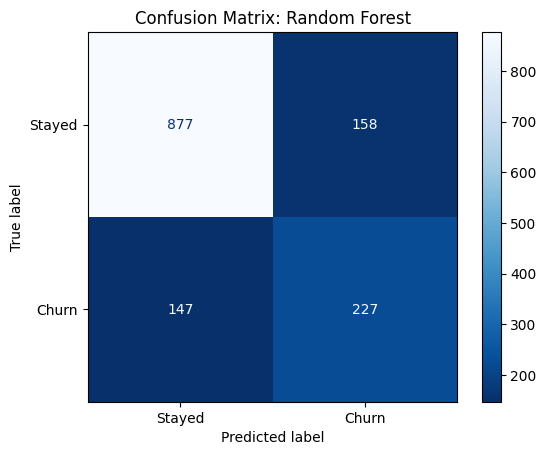


 Detailed Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1035
           1       0.59      0.61      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Train the final model
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_balanced, y_train_balanced)

#make predictions with test dataset
preds = best_model.predict(X_test_scaled)

#Display confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test_scaled, y_test,
    display_labels = ["Stayed", "Churn"], cmap ="Blues_r"
)
plt.title("Confusion Matrix: Random Forest")
plt.show()

print("\n Detailed Report:")
print(classification_report(y_test, preds))